### Chapter 8 Exercises from Del Prado Textbook

In [34]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as mpl

from sklearn.decomposition import PCA
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import log_loss, accuracy_score
from sklearn.model_selection import KFold

In [35]:
# Crazy and annoying outdated syntax from the book...

def getTestData(n_features=40, n_informative=10, n_redundant=10, n_samples=10000):
    # generate a random dataset for a classification problem
    from sklearn.datasets import make_classification

    trnsX, cont = make_classification(
        n_samples=n_samples,
        n_features=n_features,
        n_informative=n_informative,
        n_redundant=n_redundant,
        random_state=0,
        shuffle=False
    )

    df0 = pd.date_range(
        periods=n_samples,
        freq=pd.tseries.offsets.BDay(),
        end=pd.Timestamp.today()
    )

    trnsX = pd.DataFrame(trnsX, index=df0)
    cont = pd.Series(cont, index=df0).to_frame("bin")

    df0 = (
        ["I_" + str(i) for i in range(n_informative)] +
        ["R_" + str(i) for i in range(n_redundant)]
    )

    df0 += ["N_" + str(i) for i in range(n_features - len(df0))]

    trnsX.columns = df0

    cont["w"] = 1.0 / cont.shape[0]
    cont["t1"] = pd.Series(cont.index, index=cont.index)

    return trnsX, cont

def make_pca_features(X):
    pca = PCA(n_components=X.shape[1], random_state=0)
    X_pca = pca.fit_transform(X)

    X_pca = pd.DataFrame(
        X_pca,
        index=X.index,
        columns=["PCA_" + str(i) for i in range(X.shape[1])]
    )

    return X_pca, pca

def plotFeatImportance(pathOut, imp, oob, oos, method, tag=0, simNum=0, **kargs):
    # plot mean importance bars with std
    os.makedirs(pathOut, exist_ok=True)

    mpl.figure(figsize=(10, imp.shape[0] / 5.0))

    imp = imp.sort_values("mean", ascending=True)

    ax = imp["mean"].plot(
        kind="barh",
        color="b",
        alpha=0.25,
        xerr=imp["std"],
        error_kw={"ecolor": "r"}
    )

    if method == "MDI":
        mpl.xlim([0, imp.sum(axis=1).max()])
        mpl.axvline(
            1.0 / imp.shape[0],
            linewidth=1,
        color="r",
            linestyle="dotted"
        )

    ax.get_yaxis().set_visible(False)

    for i, j in zip(ax.patches, imp.index):
        ax.text(
            i.get_width() / 2,
            i.get_y() + i.get_height() / 2,
            j,
            ha="center",
            va="center",
            color="black"
        )

    mpl.title(
        "tag=" + str(tag) +
        " | simNum=" + str(simNum) +
        " | oob=" + str(round(oob, 4)) +
        " | oos=" + str(round(oos, 4))
    )

    mpl.savefig(
        pathOut + "featImportance_" + str(simNum) + ".png",
        dpi=100,
        bbox_inches="tight"
    )

    mpl.clf()
    mpl.close()

def featImpMDI(fit, featNames):
    df0 = {i: tree.feature_importances_ for i, tree in enumerate(fit.estimators_)}
    df0 = pd.DataFrame.from_dict(df0, orient="index")
    df0.columns = featNames
    df0 = df0.replace(0, np.nan)

    imp = pd.concat(
        {
            "mean": df0.mean(),
            "std": df0.std() * df0.shape[0] ** -0.5
        },
        axis=1
    )

    imp /= imp["mean"].sum()
    return imp

class PurgedKFold(KFold):
    def __init__(self, n_splits=3, t1=None, pctEmbargo=0.0):
        super().__init__(n_splits=n_splits, shuffle=False, random_state=None)
        self.t1 = t1
        self.pctEmbargo = pctEmbargo

    def split(self, X, y=None, groups=None):
        indices = np.arange(X.shape[0])
        embargo = int(X.shape[0] * self.pctEmbargo)

        for train, test in super().split(X):
            test_start = test[0]
            test_end = test[-1] + 1

            train = indices[:test_start]

            if test_end + embargo < X.shape[0]:
                train = np.concatenate((train, indices[test_end + embargo:]))

            yield train, test
def cvScore(
    clf,
    X,
    y,
    sample_weight=None,
    scoring="accuracy",
    t1=None,
    cv=None,
    cvGen=None,
    pctEmbargo=0.0
):
    if cvGen is None:
        if t1 is not None:
            cvGen = PurgedKFold(n_splits=cv, t1=t1, pctEmbargo=pctEmbargo)
        else:
            cvGen = KFold(n_splits=cv, shuffle=False)

    scores = []

    for train, test in cvGen.split(X=X):
        fit = clf.fit(
            X=X.iloc[train],
            y=y.iloc[train],
            sample_weight=sample_weight.iloc[train].values if sample_weight is not None else None
        )

        if scoring == "accuracy":
            pred = fit.predict(X.iloc[test])
            score = accuracy_score(
                y.iloc[test],
                pred,
                sample_weight=sample_weight.iloc[test].values if sample_weight is not None else None
            )

        elif scoring == "neg_log_loss":
            prob = fit.predict_proba(X.iloc[test])
            score = -log_loss(
                y.iloc[test],
                prob,
                sample_weight=sample_weight.iloc[test].values if sample_weight is not None else None,
                labels=fit.classes_)

        else:
            raise ValueError("scoring must be 'accuracy' or 'neg_log_loss'")

        scores.append(score)

    return np.array(scores)

def cvScore(
    clf,
    X,
    y,
    sample_weight=None,
    scoring="accuracy",
    t1=None,
    cv=None,
    cvGen=None,
    pctEmbargo=0.0
):
    if cvGen is None:
        if t1 is not None:
            cvGen = PurgedKFold(n_splits=cv, t1=t1, pctEmbargo=pctEmbargo)
        else:
            cvGen = KFold(n_splits=cv, shuffle=False)

    scores = []

    for train, test in cvGen.split(X=X):
        fit = clf.fit(
            X=X.iloc[train],
            y=y.iloc[train],
            sample_weight=sample_weight.iloc[train].values if sample_weight is not None else None
        )

        if scoring == "accuracy":
            pred = fit.predict(X.iloc[test])
            score = accuracy_score(
                y.iloc[test],
                pred,
                sample_weight=sample_weight.iloc[test].values if sample_weight is not None else None
            )

        elif scoring == "neg_log_loss":
            prob = fit.predict_proba(X.iloc[test])
            score = -log_loss(
                y.iloc[test],
                prob,
                sample_weight=sample_weight.iloc[test].values if sample_weight is not None else None,
                labels=fit.classes_
            )

        else:
            raise ValueError("scoring must be 'accuracy' or 'neg_log_loss'")

        scores.append(score)

    return np.array(scores)

def featImpMDA(clf, X, y, cv, sample_weight, t1, pctEmbargo, scoring="accuracy"):
    cvGen = PurgedKFold(n_splits=cv, t1=t1, pctEmbargo=pctEmbargo)

    scr0 = pd.Series(dtype=float)
    scr1 = pd.DataFrame(index=range(cv), columns=X.columns)

    for i, (train, test) in enumerate(cvGen.split(X=X)):
        X0 = X.iloc[train]
        y0 = y.iloc[train]
        w0 = sample_weight.iloc[train].values

        X1 = X.iloc[test]
        y1 = y.iloc[test]
        w1 = sample_weight.iloc[test].values

        fit = clf.fit(X0, y0, sample_weight=w0)

        if scoring == "accuracy":
            pred = fit.predict(X1)
            scr0.loc[i] = accuracy_score(y1, pred, sample_weight=w1)

        elif scoring == "neg_log_loss":
            prob = fit.predict_proba(X1)
            scr0.loc[i] = -log_loss(y1, prob, sample_weight=w1, labels=fit.classes_)

        for j in X.columns:
            X1_ = X1.copy(deep=True)
            X1_[j] = np.random.permutation(X1_[j].values)

            if scoring == "accuracy":
                pred = fit.predict(X1_)
                scr1.loc[i, j] = accuracy_score(y1, pred, sample_weight=w1)

            elif scoring == "neg_log_loss":
                prob = fit.predict_proba(X1_)
                scr1.loc[i, j] = -log_loss(y1, prob, sample_weight=w1, labels=fit.classes_)

    imp = scr0.values.reshape(-1, 1) - scr1

    imp = pd.concat({"mean": imp.mean(), "std": imp.std() * imp.shape[0] ** -0.5 }, axis=1)

    return imp, scr0.mean()

def auxFeatImpSFI(featNames, clf, trnsX, cont, scoring, cvGen):
    imp = pd.DataFrame(columns=["mean", "std"])

    for featName in featNames:
        df0 = cvScore(
            clf,
            X=trnsX[[featName]],
            y=cont["bin"],
            sample_weight=cont["w"],
            scoring=scoring,
            cvGen=cvGen
        )

        imp.loc[featName, "mean"] = df0.mean()
        imp.loc[featName, "std"] = df0.std() * df0.shape[0] ** -0.5

    return imp

# So the code provided in del prado was outdated and so I used some AI to help me make this compatible with python 3, hope that is alright. I didnt want to bother with the coding over the actual financ
    

In [36]:
# (a)
X, cont = getTestData(
    n_features=40,
    n_informative=10,
    n_redundant=10,
    n_samples=10000
)

In [37]:
# (b)
X_pca, pca = make_pca_features(X)

In [39]:
# (c)

results_81 = {}

for method in ["MDI", "MDA", "SFI"]:
    print("Running", method)

    imp, oob, oos = featImportance(
        trnsX=X_pca,
        cont=cont,
        method=method,
        n_estimators=100,
        cv=3,
        max_samples=1.0,
        scoring="accuracy",
        numThreads=1
    )

    results_81[method] = {
        "imp": imp,
        "oob": oob,
        "oos": oos
    }

    print(method)
    print("OOB:", oob)
    print("OOS:", oos)
    print(imp.sort_values("mean", ascending=False).head())

Running MDI
MDI
OOB: 0.8517
OOS: 0.4531136376985028
           mean       std
PCA_3  0.046963  0.001656
PCA_1  0.045546  0.001670
PCA_8  0.045217  0.001541
PCA_6  0.039027  0.001348
PCA_9  0.036715  0.001327
Running MDA
MDA
OOB: 0.8572
OOS: 0.45911465771652155
            mean       std
PCA_3   0.040502  0.024343
PCA_9   0.022399  0.009425
PCA_34  0.017999  0.007188
PCA_5   0.015401  0.014514
PCA_6   0.014801  0.010314
Running SFI
SFI
OOB: 0.8568
OOS: 0.4507140576085203
            mean       std
PCA_9   0.507002  0.016681
PCA_6   0.499904  0.018857
PCA_3   0.483603  0.029108
PCA_7   0.481304   0.02538
PCA_34  0.480703  0.020919


In [40]:
for method in ["MDI", "MDA", "SFI"]:
    plotFeatImportance(
        pathOut="./testFunc/",
        imp=results_81[method]["imp"],
        oob=results_81[method]["oob"],
        oos=results_81[method]["oos"],
        method=method,
        tag="8.1",
        simNum="8.1_" + method
    )

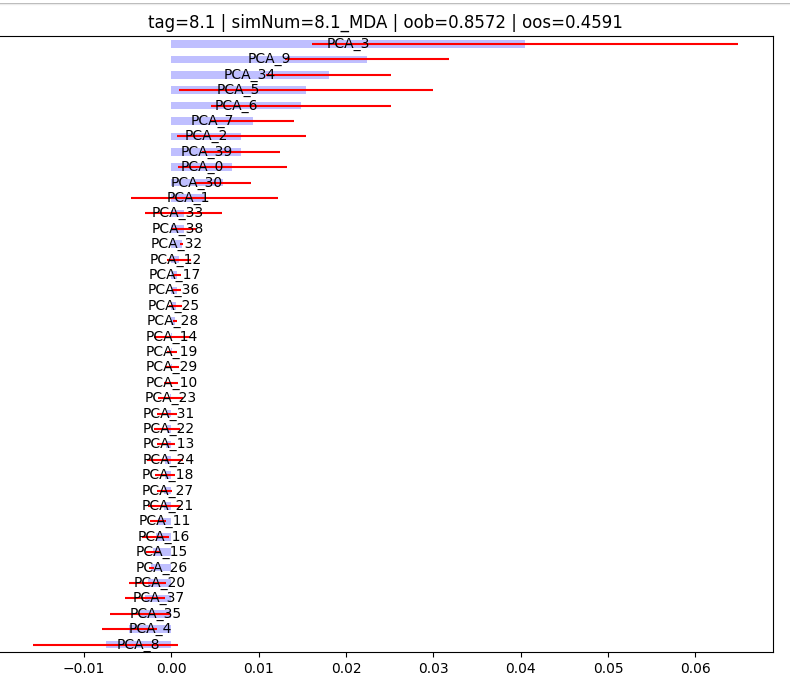

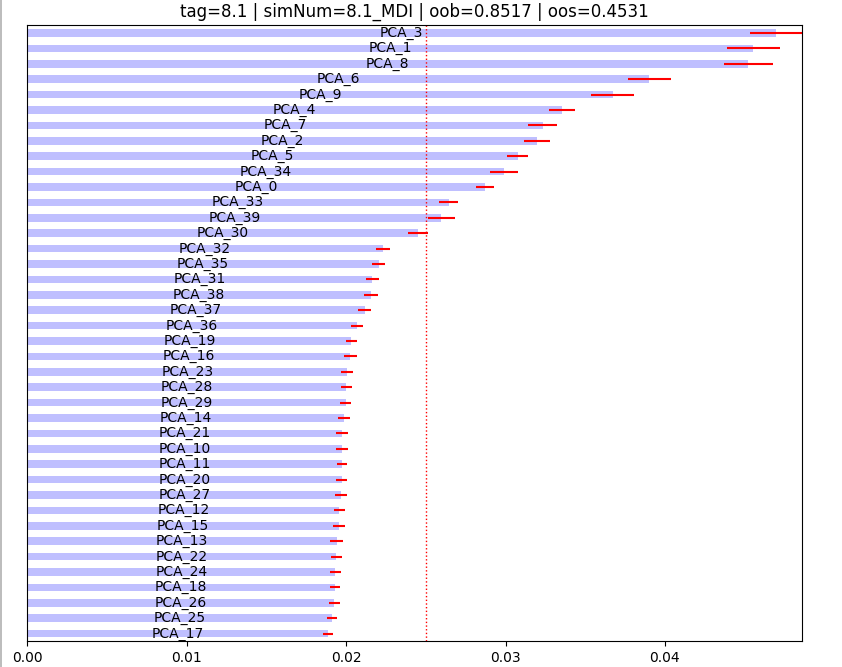

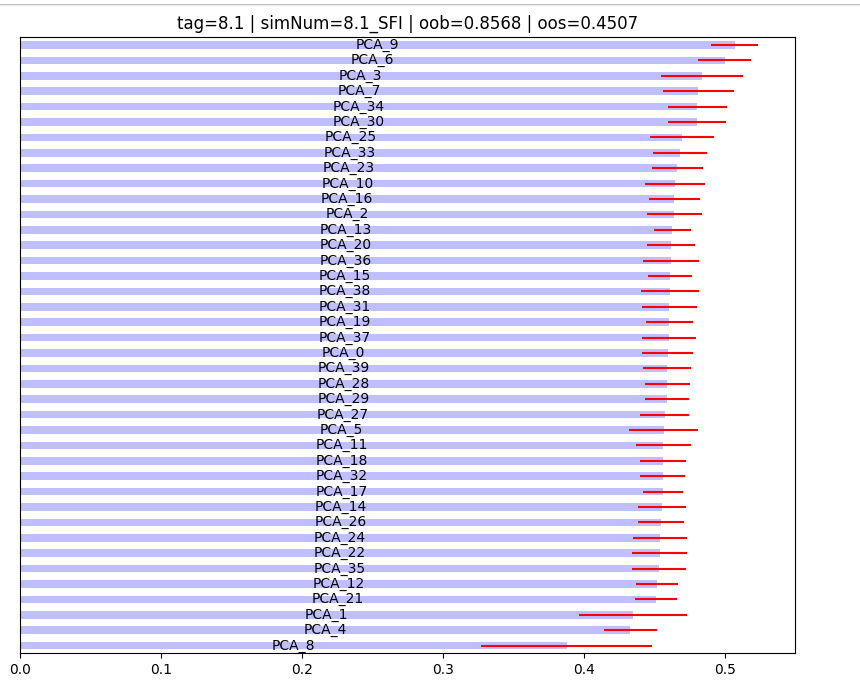